# 🌌 GalaxyMorph — Layer 3: Grad-CAM Interpretability

**Goal:** Explain *why* the Layer 1 model predicts a galaxy as:

- elliptical
- spiral
- irregular

We use **Grad-CAM** on the best fine-tuned Layer 1 ResNet-18 model and visualize:

- correct predictions
- failure cases
- model attention regions

# 1. Paths and Imports
This loads:

- the Layer 1 model weights
- the Layer 1 test split
- the competition dataset images

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

In [3]:
# Competition dataset
COMP_DIR = Path("/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge")

# Layer 1 outputs
LAYER1_DIR = Path("/kaggle/input/datasets/reihanehshahri/layer1")

MODEL_PATH = LAYER1_DIR / "best_resnet18_layer1_finetuned.pt"
TEST_SPLIT_CSV = LAYER1_DIR / "test_split.csv"

print("Model exists:", MODEL_PATH.exists())
print("Test split exists:", TEST_SPLIT_CSV.exists())

Model exists: True
Test split exists: True


# 2. Extract training images if needed

The test split points to training-set galaxy IDs, so we need the training image folder.

In [4]:
import zipfile

WORK_DIR = Path("/kaggle/working")
IMG_DIR = WORK_DIR / "images_training_rev1"

if not IMG_DIR.exists():
    with zipfile.ZipFile(COMP_DIR / "images_training_rev1.zip", "r") as z:
        z.extractall(WORK_DIR)

print("IMG_DIR exists:", IMG_DIR.exists())
print("Example image:", next(IMG_DIR.glob("*.jpg")).name)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
IMG_DIR exists: True
Example image: 910288.jpg


# 3. Load test split and rebuild filepaths

Our saved CSV may have old paths from another session, so we rebuild them safely from ``GalaxyID``.

In [5]:
test_df = pd.read_csv(TEST_SPLIT_CSV)
print(test_df.shape)
test_df.head()

(2528, 45)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class11.4,Class11.5,Class11.6,p_elliptical,p_spiral,p_irregular,p_max,label,label_name,filepath
0,456095,0.815997,0.183025,0.000978,0.01823,0.164795,0.000000,0.164795,0.0,0.164795,...,0.0,0.0,0.0,0.815997,0.003337,0.022946,0.815997,0,elliptical,/kaggle/working/images_training_rev1/456095.jpg
1,831845,0.927342,0.071038,0.001620,0.00000,0.071038,0.000000,0.071038,0.0,0.071038,...,0.0,0.0,0.0,0.927342,0.000000,0.001622,0.927342,0,elliptical,/kaggle/working/images_training_rev1/831845.jpg
2,259687,0.804065,0.157281,0.038654,0.00000,0.157281,0.000000,0.157281,0.0,0.157281,...,0.0,0.0,0.0,0.804065,0.000000,0.000000,0.804065,0,elliptical,/kaggle/working/images_training_rev1/259687.jpg
3,277026,0.838641,0.161359,0.000000,0.04034,0.121019,0.064203,0.056817,0.0,0.121019,...,0.0,0.0,0.0,0.838641,0.006509,0.000000,0.838641,0,elliptical,/kaggle/working/images_training_rev1/277026.jpg
4,894811,0.865245,0.119305,0.015450,0.00000,0.119305,0.000000,0.119305,0.0,0.119305,...,0.0,0.0,0.0,0.865245,0.000000,0.018147,0.865245,0,elliptical,/kaggle/working/images_training_rev1/894811.jpg


In [6]:
# Rebuild filepaths from GalaxyID for this notebook/session
test_df["filepath"] = test_df["GalaxyID"].apply(lambda x: str(IMG_DIR / f"{int(x)}.jpg"))

# Keep only rows whose files exist
test_df = test_df[test_df["filepath"].apply(lambda p: Path(p).exists())].copy().reset_index(drop=True)

print("Usable test samples:", len(test_df))
test_df[["GalaxyID", "label", "label_name", "filepath"]].head()

Usable test samples: 2528


,GalaxyID,label,label_name,filepath
0,456095,0,elliptical,/kaggle/working/images_training_rev1/456095.jpg
1,831845,0,elliptical,/kaggle/working/images_training_rev1/831845.jpg
2,259687,0,elliptical,/kaggle/working/images_training_rev1/259687.jpg
3,277026,0,elliptical,/kaggle/working/images_training_rev1/277026.jpg
4,894811,0,elliptical,/kaggle/working/images_training_rev1/894811.jpg


# 4. Rebuild the Layer 1 model and load weights

We use the hard-label Layer 1 model, because Grad-CAM is cleanest on class predictions.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

label_names = {0: "elliptical", 1: "spiral", 2: "irregular"}

device: cuda


# 5. Dataset and Transforms for Inference

In [8]:
IMG_SIZE = 224

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class GalaxyGradCAMDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        x = self.transform(img)
        y = int(row["label"])
        return x, y, row["filepath"], int(row["GalaxyID"])

test_loader = DataLoader(
    GalaxyGradCAMDataset(test_df, eval_tfms),
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 6. Run inference on the whole test set

We need:

- true labels
- predicted labels
- confidence

Then we can choose correct and failure cases.

In [9]:
all_preds = []
all_labels = []
all_probs = []
all_paths = []
all_ids = []

softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for x, y, paths, galaxy_ids in test_loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = softmax(logits).cpu().numpy()
        preds = probs.argmax(axis=1)

        all_preds.append(preds)
        all_labels.append(y.numpy())
        all_probs.append(probs)
        all_paths.extend(list(paths))
        all_ids.extend(list(galaxy_ids.numpy()))

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

results_df = pd.DataFrame({
    "GalaxyID": all_ids,
    "filepath": all_paths,
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs.max(axis=1),
})

results_df["true_name"] = results_df["true_label"].map(label_names)
results_df["pred_name"] = results_df["pred_label"].map(label_names)
results_df["correct"] = results_df["true_label"] == results_df["pred_label"]

results_df.head()

,GalaxyID,filepath,true_label,pred_label,confidence,true_name,pred_name,correct
0,456095,/kaggle/working/images_training_rev1/456095.jpg,0,0,0.941425,elliptical,elliptical,True
1,831845,/kaggle/working/images_training_rev1/831845.jpg,0,0,0.999901,elliptical,elliptical,True
2,259687,/kaggle/working/images_training_rev1/259687.jpg,0,0,0.999799,elliptical,elliptical,True
3,277026,/kaggle/working/images_training_rev1/277026.jpg,0,0,0.996166,elliptical,elliptical,True
4,894811,/kaggle/working/images_training_rev1/894811.jpg,0,0,0.996236,elliptical,elliptical,True


# 7. Quick summary of correct vs wrong

In [10]:
print("Total test samples:", len(results_df))
print("Correct:", results_df["correct"].sum())
print("Wrong:", (~results_df["correct"]).sum())

print("\nCorrect by class:")
print(results_df[results_df["correct"]]["true_name"].value_counts())

print("\nWrong by class:")
print(results_df[~results_df["correct"]]["true_name"].value_counts())

Total test samples: 2528
Correct: 2415
Wrong: 113

Correct by class:
true_name
elliptical    2026
spiral         230
irregular      159
Name: count, dtype: int64

Wrong by class:
true_name
elliptical    96
irregular     11
spiral         6
Name: count, dtype: int64


# 8. Grad-CAM implementation

This is the heart of the notebook.

We use ``model.layer4`` as the target layer because it is the last convolutional block in ResNet-18.

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.zero_grad()

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        # Grad-CAM weights: global average pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted sum of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        # Normalize
        cam = F.interpolate(cam, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, class_idx

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

gradcam = GradCAM(model, model.layer4)

# 9. Helper functions for visualization

We’ll show:

- original image
- heatmap
- overlay

In [14]:
def denormalize_image(x_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = x_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def load_transformed_image(filepath):
    img = Image.open(filepath).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    return img, x

def show_gradcam(filepath, true_label, pred_label, confidence, class_idx=None, figsize=(10,3)):
    pil_img, x = load_transformed_image(filepath)
    cam, used_class = gradcam.generate(x, class_idx=class_idx)

    img_np = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    heatmap = plt.cm.jet(cam)[..., :3]  # RGB heatmap
    overlay = 0.55 * img_np + 0.45 * heatmap
    overlay = np.clip(overlay, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Overlay\nT:{label_names[true_label]} | P:{label_names[pred_label]} ({confidence:.2f})"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# 10. Inspect a few single examples first

Before making galleries, test a few examples manually.

**Correct example**

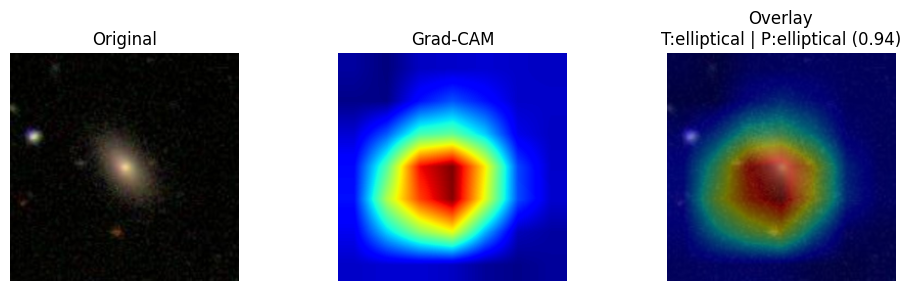

In [15]:
correct_example = results_df[results_df["correct"]].iloc[0]
show_gradcam(
    filepath=correct_example["filepath"],
    true_label=int(correct_example["true_label"]),
    pred_label=int(correct_example["pred_label"]),
    confidence=float(correct_example["confidence"])
)

**Wrong example**

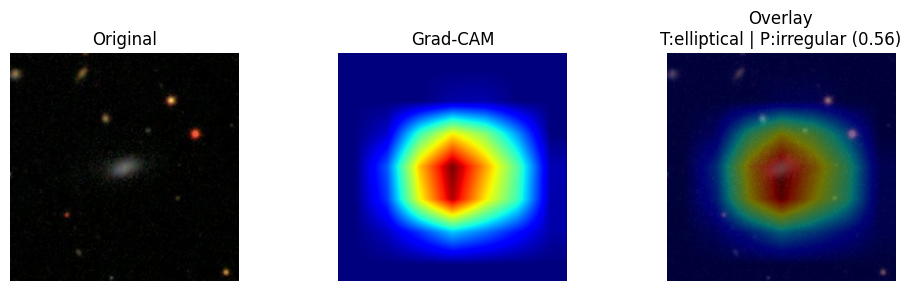

In [16]:
wrong_example = results_df[~results_df["correct"]].iloc[0]
show_gradcam(
    filepath=wrong_example["filepath"],
    true_label=int(wrong_example["true_label"]),
    pred_label=int(wrong_example["pred_label"]),
    confidence=float(wrong_example["confidence"])
)

# 11. Build sample sets for the gallery

We want:

- correct predictions from each class
- confident wrong predictions

In [17]:
# Correct examples by class
correct_elliptical = results_df[(results_df["correct"]) & (results_df["true_label"] == 0)].sample(min(4, len(results_df[(results_df["correct"]) & (results_df["true_label"] == 0)])), random_state=42)
correct_spiral     = results_df[(results_df["correct"]) & (results_df["true_label"] == 1)].sample(min(4, len(results_df[(results_df["correct"]) & (results_df["true_label"] == 1)])), random_state=42)
correct_irregular  = results_df[(results_df["correct"]) & (results_df["true_label"] == 2)].sample(min(4, len(results_df[(results_df["correct"]) & (results_df["true_label"] == 2)])), random_state=42)

# Most confident mistakes
wrong_confident = results_df[~results_df["correct"]].sort_values("confidence", ascending=False).head(8)

print("Correct elliptical:", len(correct_elliptical))
print("Correct spiral:", len(correct_spiral))
print("Correct irregular:", len(correct_irregular))
print("Confident wrong:", len(wrong_confident))

Correct elliptical: 4
Correct spiral: 4
Correct irregular: 4
Confident wrong: 8


# 12. Gallery function

This just loops through a dataframe and shows Grad-CAM results one by one.

In [18]:
def gradcam_gallery(df_subset, title):
    print(f"\n=== {title} ===\n")
    for _, row in df_subset.iterrows():
        show_gradcam(
            filepath=row["filepath"],
            true_label=int(row["true_label"]),
            pred_label=int(row["pred_label"]),
            confidence=float(row["confidence"])
        )

# 13. Run the galleries

**Correct predictions**


=== Correct Elliptical Predictions ===



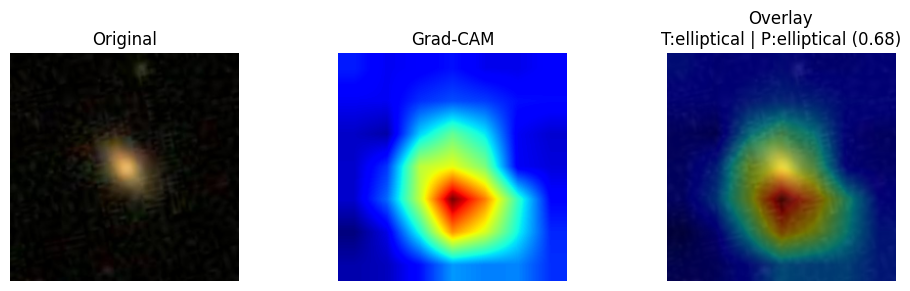

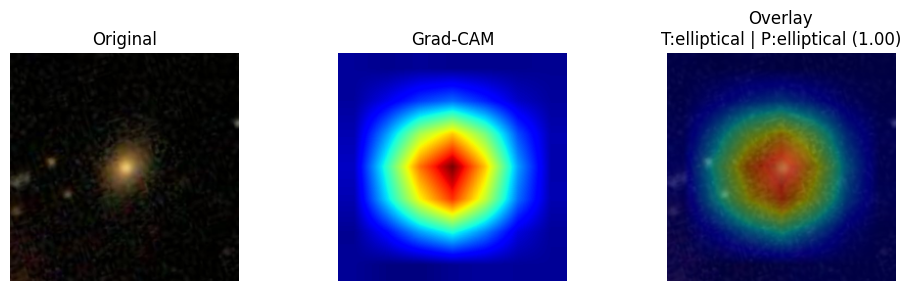

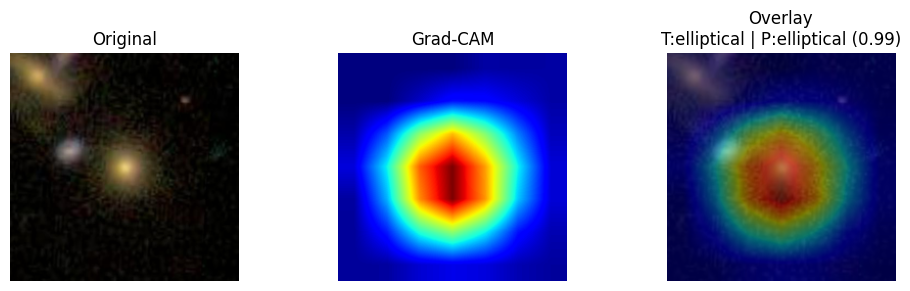

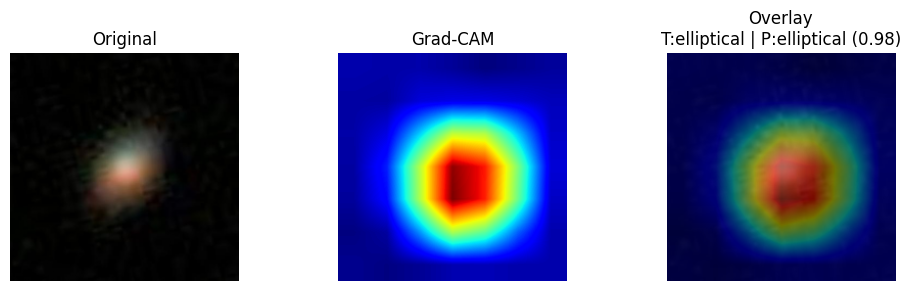


=== Correct Spiral Predictions ===



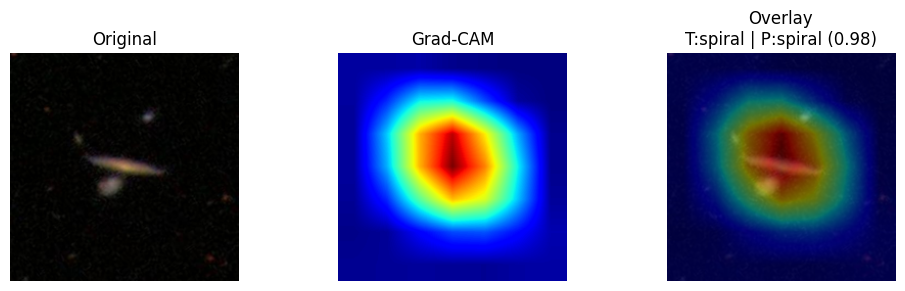

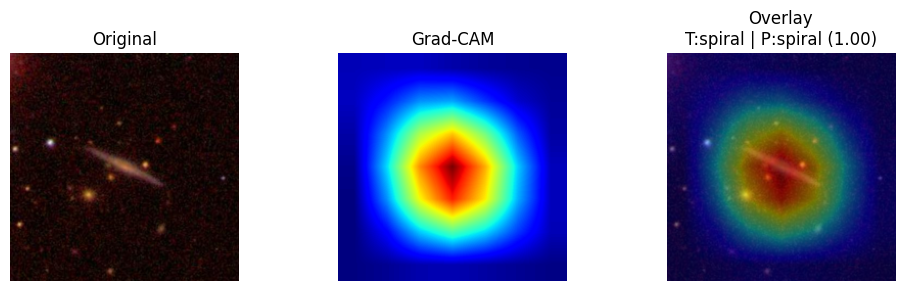

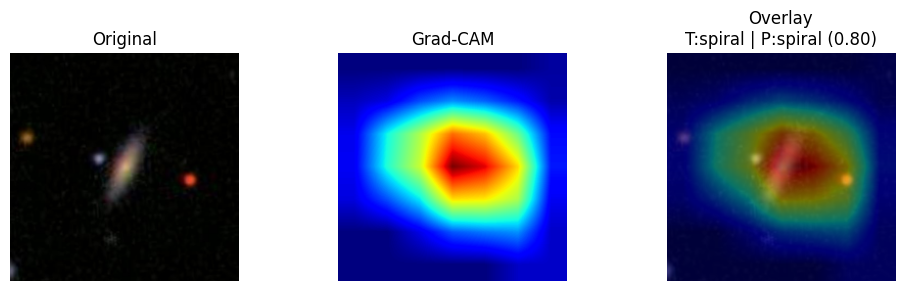

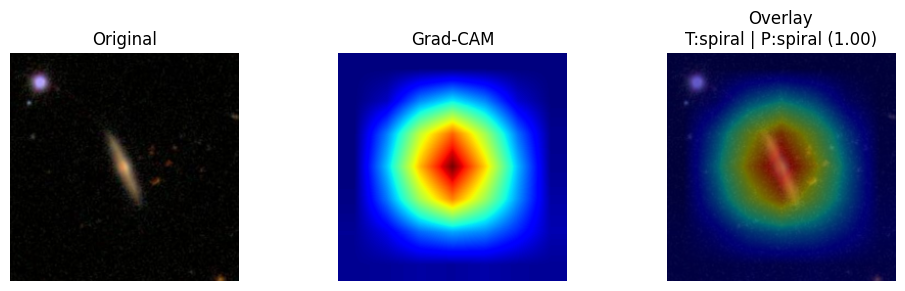


=== Correct Irregular Predictions ===



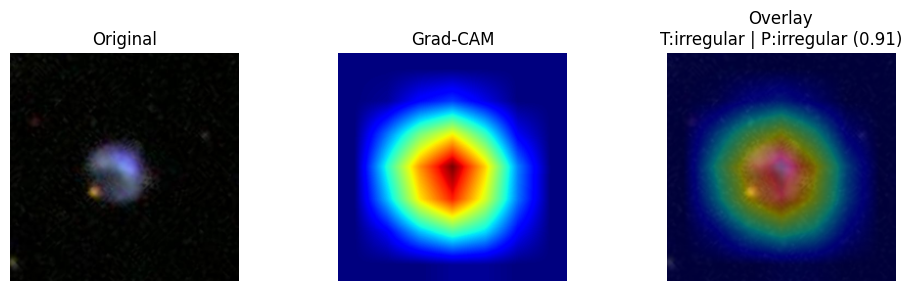

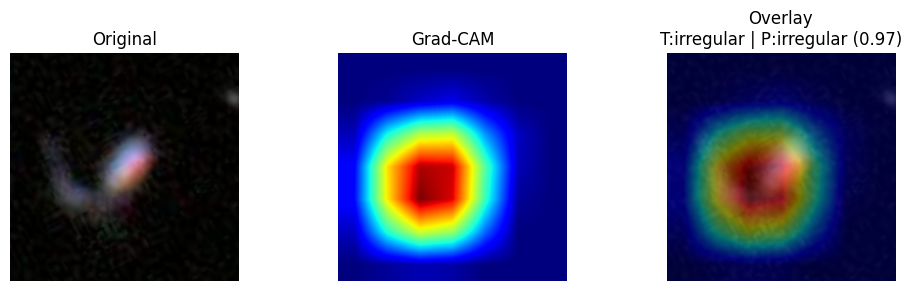

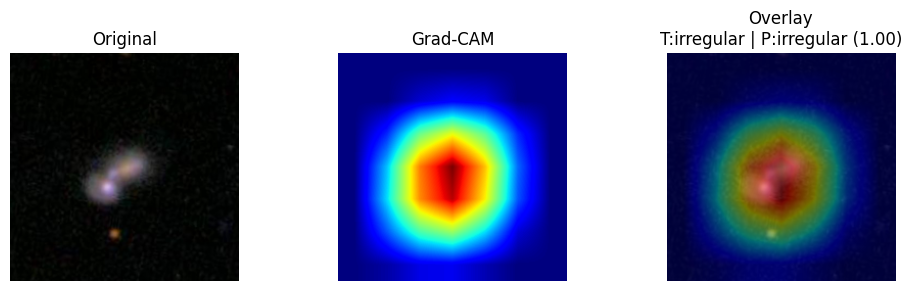

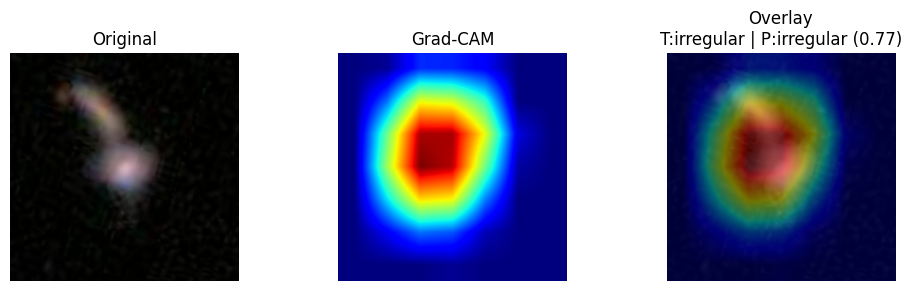

In [19]:
gradcam_gallery(correct_elliptical, "Correct Elliptical Predictions")
gradcam_gallery(correct_spiral, "Correct Spiral Predictions")
gradcam_gallery(correct_irregular, "Correct Irregular Predictions")

**Failure cases**


=== Most Confident Wrong Predictions ===



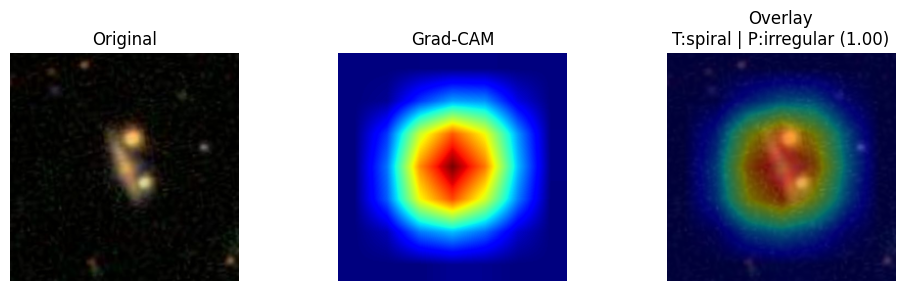

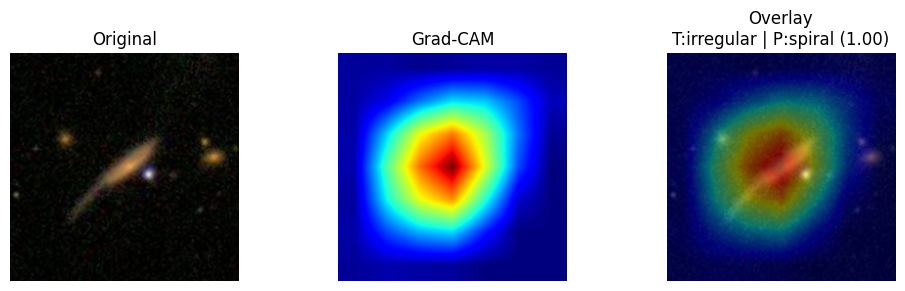

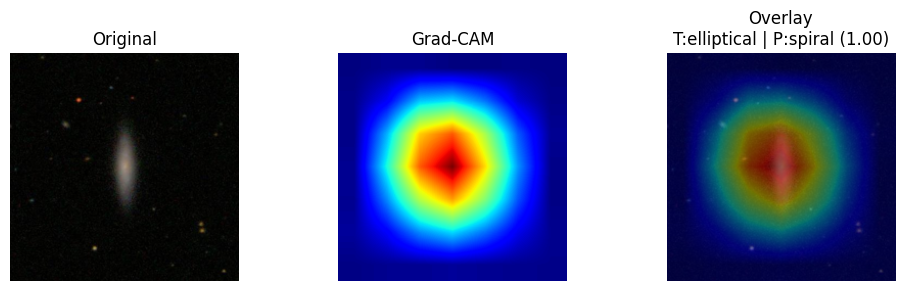

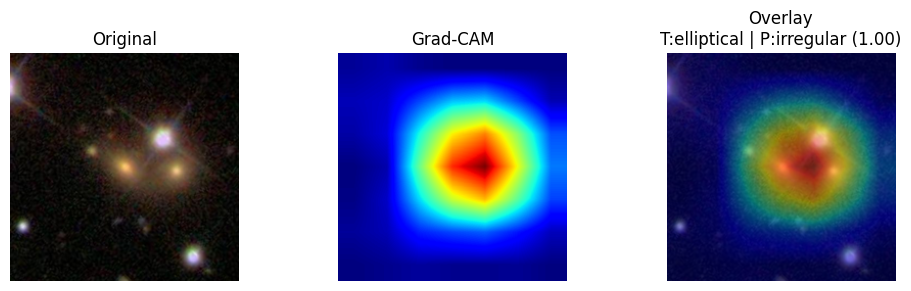

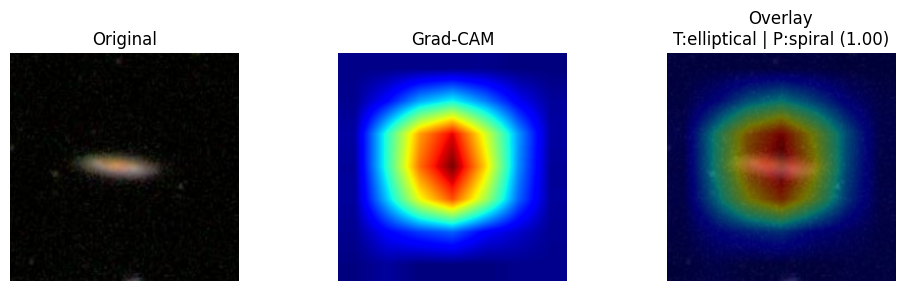

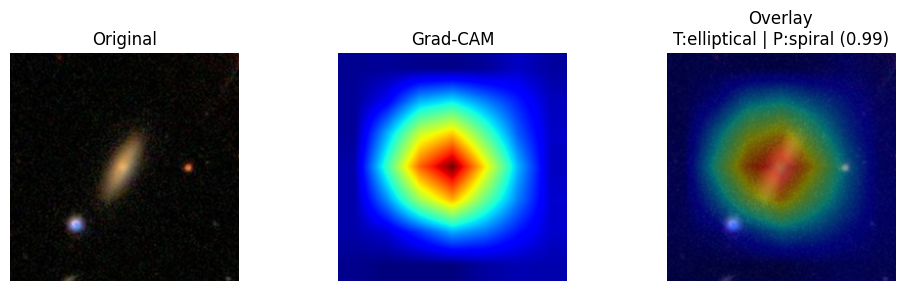

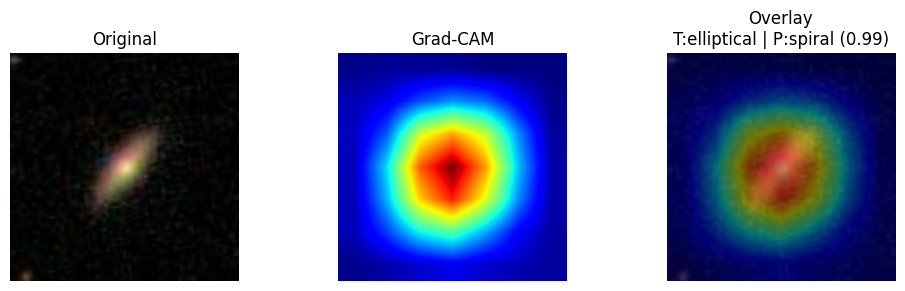

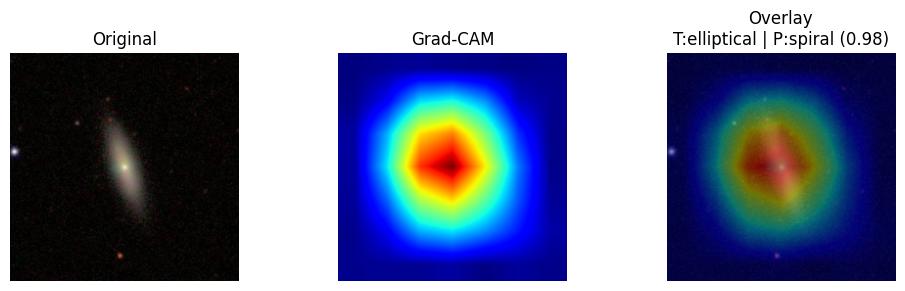

In [20]:
gradcam_gallery(wrong_confident, "Most Confident Wrong Predictions")

## Layer 3 Observations

### Correct predictions
- Elliptical galaxies: the model often focuses on the central smooth light profile.
- Spiral galaxies: attention frequently falls on visible arm structure and disk regions.
- Irregular galaxies: attention is more spatially diffuse and often follows clumpy/asymmetric regions.

### Failure cases
- Some spirals are misread when arms are faint and the bulge dominates.
- Some irregulars are confused with ellipticals when the object appears compact or smooth.
- In a few cases, attention appears too concentrated on the core, suggesting loss of faint outer structure.